In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

In [5]:
os.listdir('data/gender_dataset')

['men', 'women']

In [6]:
# temp_image = mpimg.imread('animals/cat/00499-200124809.png')

In [7]:
# temp_image.shape

In [8]:
# plt.imshow(temp_image)

In [9]:
data = {
    'men':0,
    'women':1
}

In [10]:
X_train = []
y_train = []
for i in os.listdir('data/gender_dataset/'):
    for j in os.listdir(f'data/gender_dataset/{i}/'):
        image = mpimg.imread(f'data/gender_dataset/{i}/{j}')
        image = cv2.resize(image, (200, 200))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = image.reshape(200, 200, 1)
        X_train.append(image)
        y_train.append(data[i])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [13]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [14]:
from keras.utils import to_categorical

In [15]:
y_train = to_categorical(y_train, num_classes=2)

In [63]:
from keras import Sequential
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [94]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(200, 200, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units=64, activation='relu'))
Dropout(0.3)
model.add(Dense(units=32, activation='relu'))
Dropout(0.3)
model.add(Dense(units=16, activation='relu'))
Dropout(0.3)
model.add(Dense(units=2, activation='softmax'))

C:\Users\emeks\Desktop\kaggle_noetbooks\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'], )

In [96]:
model.fit(X_train, y_train, validation_split=0.15, epochs=20)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 440ms/step - accuracy: 0.4969 - loss: 172.4710 - val_accuracy: 0.5224 - val_loss: 15.6818
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 430ms/step - accuracy: 0.5410 - loss: 5.6806 - val_accuracy: 0.5771 - val_loss: 2.4497
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 433ms/step - accuracy: 0.7052 - loss: 1.1361 - val_accuracy: 0.5771 - val_loss: 1.0619
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 430ms/step - accuracy: 0.8102 - loss: 0.5621 - val_accuracy: 0.5672 - val_loss: 1.2567
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 431ms/step - accuracy: 0.8861 - loss: 0.4032 - val_accuracy: 0.6020 - val_loss: 0.9587
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 434ms/step - accuracy: 0.9082 - loss: 0.3022 - val_accuracy: 0.5871 - val_loss: 1.5726
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 434ms/step - accuracy: 0.9294 - loss: 0.3475 - val_accuracy: 0.5871 - val_loss: 1.0215
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 430ms/step - accuracy: 0.9532 - loss: 0.2109 - val_a

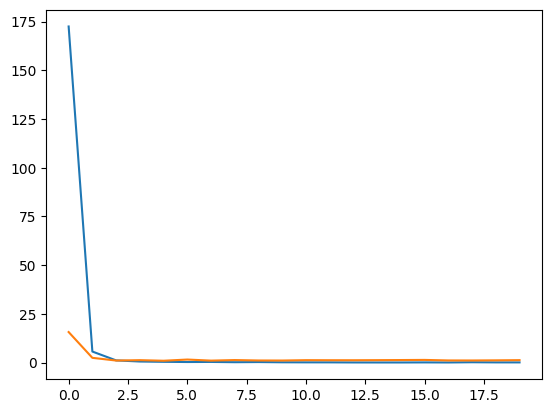

In [97]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

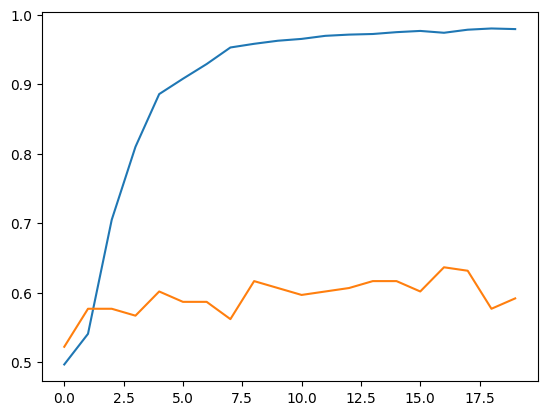

In [98]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [99]:
test_image = mpimg.imread('download (2).jpg')

In [100]:
test_image = cv2.resize(test_image, (200, 200))
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
test_image = test_image.reshape(1, 200, 200, 1)

In [101]:
prediction = model.predict(test_image)
class_index = np.argmax(prediction)

print("Predicted class:", class_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted class: 1


In [102]:
from sklearn.metrics import accuracy_score, mean_absolute_error

In [103]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


In [104]:
acc = accuracy_score(y_test, y_pred_classes)
mae = mean_absolute_error(y_test, y_pred_classes)

In [105]:
print(f'Accuracy: {acc}')
print(f'mean absolute error: {mae}')

Accuracy: 0.6467065868263473
mean absolute error: 0.3532934131736527


In [106]:
print(np.unique(y_train))

[0. 1.]
